# Mercado Imobiliário Brasileiro
**Guilherme Familiar do Amaral — G1, Tema 12**

## 1. Introdução e problema
Investigar diferenças de preço entre cidades, regiões e tipos de imóvel, evolução temporal e associação com área e renda. A base é simulada: não representa transações reais nem permite recomendações de investimento. Localização, tamanho e renda são hipóteses de fatores associados aos preços, a serem examinadas sem supor causalidade.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd()/'analise.py').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sqlalchemy import create_engine, text
from analise import carregar, persistir, ranking, crescimento, conclusao, brl
sns.set_theme(style='whitegrid', palette='crest')
IMAGENS = ROOT/'imagens'
IMAGENS.mkdir(exist_ok=True)

## 2. Base e leitura
Fonte: repositório Dados-Simulados-G1 do professor Alexandre Louzada. Arquivo `simulacao_mercado_imobiliario_brasil.csv`. Cada linha é uma observação simulada de cidade/mês com atributos de imóvel. Não existe identificador para acompanhar o mesmo imóvel ao longo do tempo.

Colunas: ano, mês e data; região, UF, cidade e bairro; tipo, área, quartos e vagas; preço total, preço/m², renda média, juros e nível de preço. Renda e juros são variáveis simuladas. A periodicidade/unidade precisa da renda não é documentada; a razão preço/renda não será interpretada como anos ou meses para comprar um imóvel.

In [2]:
bruto = pd.read_csv(ROOT/'dados/simulacao_mercado_imobiliario_brasil.csv')
print('Dimensões:', bruto.shape)
display(bruto.head())
display(bruto.dtypes.to_frame('Tipo original'))

,ano,mes,data,regiao,uf,cidade,bairro,tipo_imovel,area_m2,quartos,vagas_garagem,preco_imovel,preco_m2,renda_media,taxa_juros,nivel_preco
0,2015,1,2015-01-01,Norte,AM,Manaus,Boa Vista,Casa,162,4,3,696835.01,3946.50,2069.62,13.92,Luxo
1,2015,1,2015-01-01,Norte,PA,Belém,Boa Vista,Studio,46,3,2,299378.31,9805.85,2977.65,11.10,Baixo
2,2015,1,2015-01-01,Norte,PA,Santarém,Centro,Cobertura,159,2,1,324224.24,17435.31,4546.93,11.88,Baixo
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Boa Vista,Studio,104,4,2,149498.43,14149.33,4208.43,7.06,Médio
4,2015,1,2015-01-01,Norte,TO,Palmas,Boa Vista,Studio,182,0,3,283616.71,9447.97,2753.91,8.64,Baixo


,Tipo original
ano,int64
mes,int64
data,object
regiao,object
uf,object
cidade,object
bairro,object
tipo_imovel,object
area_m2,int64
quartos,int64


Dimensões: (4440, 16)


## 3. Limpeza e preparação
Verificação de nulos, duplicatas, conversão numérica e de datas. Linhas sem campos essenciais ou com preço, área ou renda não positivos são excluídas. Datas determinam ano e mês. Valores extremos são sinalizados pelo limite superior de 1,5 IQR e preservados: preço elevado não significa erro. A função compartilhada `carregar` mantém notebook e dashboard consistentes.

In [3]:
display(bruto.isna().sum().to_frame('Nulos'))
print('Duplicatas:', bruto.duplicated().sum())
df, auditoria = carregar()
display(pd.Series(auditoria).to_frame('Quantidade'))
print('Cidades:', df.cidade.nunique(), '| UFs:', df.uf.nunique(), '| Regiões:', df.regiao.nunique())

,Nulos
ano,0
mes,0
data,0
regiao,0
uf,0
cidade,0
bairro,0
tipo_imovel,0
area_m2,0
quartos,0


,Quantidade
registros_originais,4440
duplicadas_removidas,0
invalidos_removidos,0
registros_validos,4440
divergencias_preco_m2,4440
outliers_preservados,248


Duplicatas: 0
Cidades: 37 | UFs: 20 | Regiões: 5


## 4. Engenharia de atributos
`preco_m2_calculado = preco_imovel / area_m2`; `divergencia_m2` compara o cálculo à coluna original com tolerância de R$ 0,01. `outlier_preco` sinaliza valores extremos. `preco_renda` é uma razão exploratória, sem interpretação temporal. `nivel_preco` é preservado como categoria original, pois seus limites não estão documentados.

O indicador de preço/m² será a **média simples dos preços/m² calculados**, não a razão entre as somas de preços e áreas.

In [4]:
display(df[['preco_imovel','area_m2','preco_m2','preco_m2_calculado','divergencia_m2']].head(10))
print(f"Divergência em {df.divergencia_m2.mean():.1%} dos registros válidos.")

,preco_imovel,area_m2,preco_m2,preco_m2_calculado,divergencia_m2
0,696835.01,162,3946.50,4301.450679,True
21,93595.32,74,11755.12,1264.801622,True
22,711624.92,140,11564.40,5083.035143,True
23,1297725.67,119,16620.18,10905.257731,True
24,1332388.49,194,11352.40,6867.981907,True
25,530286.34,52,15068.41,10197.814231,True
26,318135.27,96,8457.71,3313.909063,True
28,3288685.04,87,12703.41,37800.977471,True
29,1693477.22,78,16850.70,21711.246410,True
30,863783.30,156,8974.27,5537.072436,True


Divergência em 100.0% dos registros válidos.


## 5. Análise exploratória e KPIs
As médias são da amostra, sem ponderação populacional. O tipo com maior valor corresponde ao maior preço médio observado, não à maior valorização temporal.

In [5]:
display(df[['preco_imovel','preco_m2_calculado','area_m2','renda_media']].describe())
kpis = {'Preço médio': brl(df.preco_imovel.mean()), 'Preço médio/m² calculado': brl(df.preco_m2_calculado.mean()), 'Cidade mais cara': ranking(df,'cidade').index[0], 'Região mais cara': ranking(df,'regiao').index[0], 'Tipo com maior preço médio': ranking(df,'tipo_imovel').index[0], 'Crescimento médio anual': f'{crescimento(df):.2f}%'}
display(pd.Series(kpis).to_frame('Resultado'))

,preco_imovel,preco_m2_calculado,area_m2,renda_media
count,4.440000e+03,4440.000000,4440.000000,4440.000000
mean,6.822993e+05,7251.851707,123.100450,3498.048619
std,5.320012e+05,7786.857589,54.962727,706.411642
min,5.467454e+04,298.197614,30.000000,952.000000
25%,3.390784e+05,2687.436969,76.000000,3012.700000
50%,5.376452e+05,4779.625687,121.000000,3515.400000
75%,8.575030e+05,8890.120669,171.000000,3975.582500
max,6.416336e+06,106041.252812,219.000000,6341.420000


,Resultado
Preço médio,"R$ 682.299,26"
Preço médio/m² calculado,"R$ 7.251,85"
Cidade mais cara,Serra
Região mais cara,Sul
Tipo com maior preço médio,Apartamento
Crescimento médio anual,0.32%


## 6. Evolução temporal
Comparamos média e mediana mensais. O crescimento médio anual é a média aritmética das taxas entre anos consecutivos com os mesmos meses disponíveis. Variações são nominais, sem ajuste de inflação e sem controlar a composição dos imóveis.

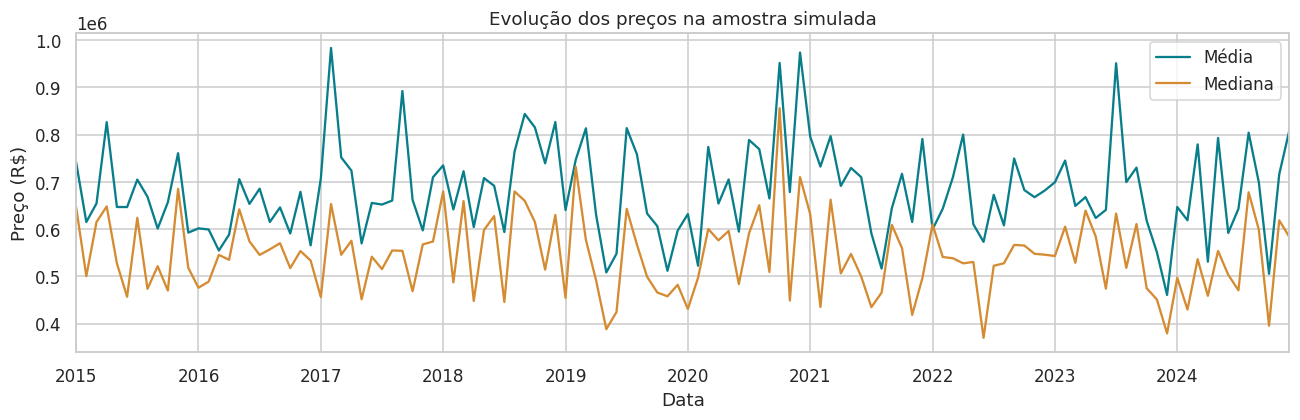

,Preço médio,Variação anual (%)
ano,,
2015,676377.247005,NaN
2016,623833.437635,-7.768418
2017,713784.304077,14.419052
2018,723842.775450,1.409175
2019,650647.907770,-10.111984
2020,725763.907523,11.544800
2021,694201.534234,-4.348849
2022,666595.078716,-3.976721
2023,669714.875946,0.468020


Anos com queda da média: [2016, 2019, 2021, 2022]
Anos com alta da média: [2017, 2018, 2020, 2023, 2024]


In [6]:
mensal = df.groupby('data').preco_imovel.agg(['mean','median'])
fig, ax = plt.subplots(figsize=(12,4))
mensal.rename(columns={'mean':'Média','median':'Mediana'}).plot(ax=ax, color=['#087e8b','#d58b32'])
ax.set(xlabel='Data', ylabel='Preço (R$)', title='Evolução dos preços na amostra simulada')
fig.tight_layout(); fig.savefig(IMAGENS/'evolucao.png',dpi=160); plt.show()
anual = df.groupby('ano').preco_imovel.mean().to_frame('Preço médio')
anual['Variação anual (%)'] = anual['Preço médio'].pct_change()*100
display(anual)
print('Anos com queda da média:', anual.index[anual['Variação anual (%)'] < 0].tolist())
print('Anos com alta da média:', anual.index[anual['Variação anual (%)'] > 0].tolist())

Altas e quedas são movimentos da média simulada. Não bastam para afirmar aquecimento ou retração reais: faltam volume de transações, tempo de venda, inflação e controle de qualidade dos imóveis.

## 7. Cidades, regiões e tipos

,mean,median,count
cidade,,,
Serra,792619.443833,603463.510,120
Florianópolis,767402.689500,618555.470,120
Campo Grande,762923.719167,551421.210,120
Santarém,746311.010583,582702.665,120
Londrina,740187.246250,556923.065,120
Campinas,734155.265750,582359.130,120
São Paulo,730776.435917,575830.645,120
Aparecida de Goiânia,728688.075833,569886.525,120
Juiz de Fora,720678.941583,569970.900,120


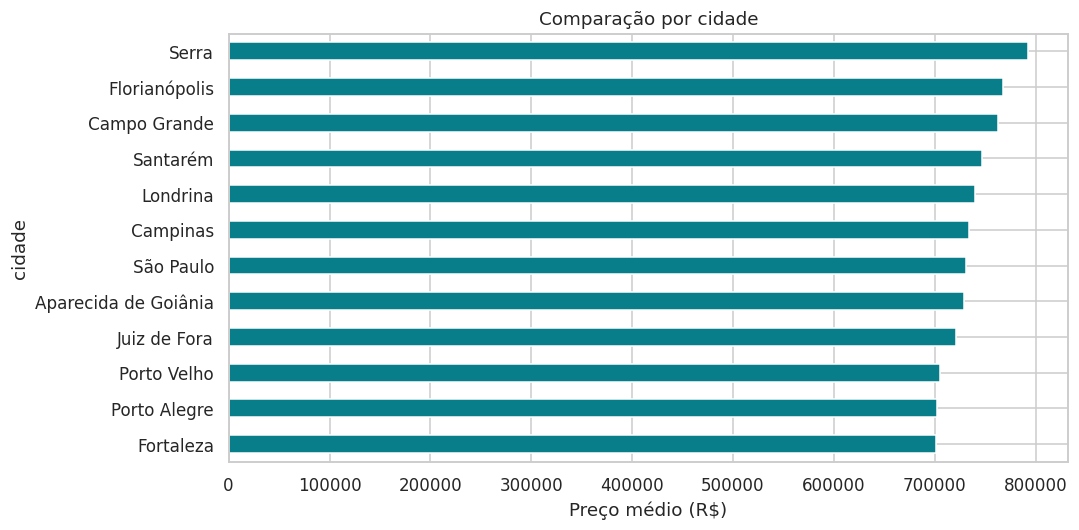

,mean,median,count
regiao,,,
Sul,695079.957444,567830.090,720
Norte,691901.834567,529793.620,600
Sudeste,690182.869269,536526.155,1560
Centro-Oeste,689971.814200,543531.360,600
Nordeste,649105.927042,513066.325,960


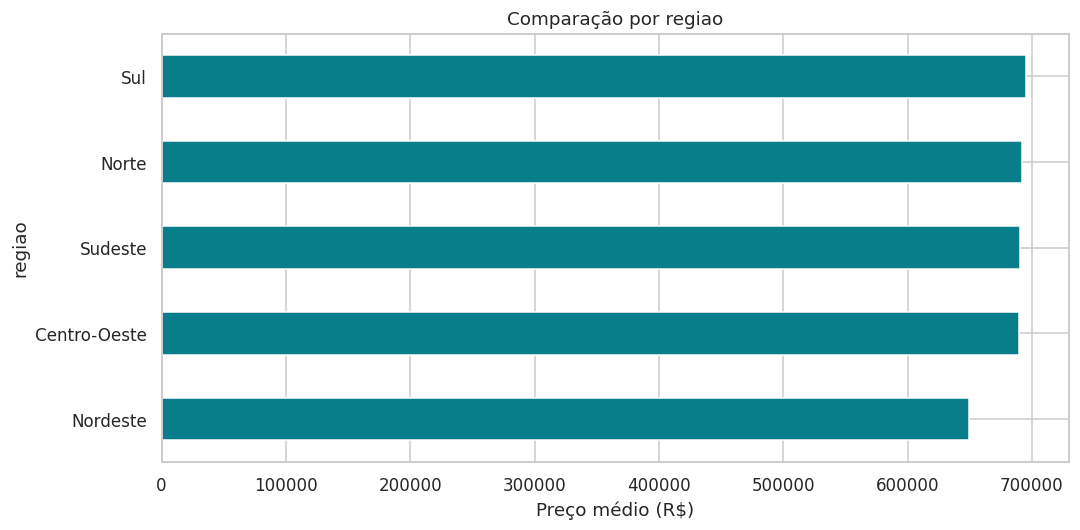

,mean,median,count
tipo_imovel,,,
Apartamento,705591.900287,550529.720,837
Studio,689849.096360,534395.845,890
Sala Comercial,686118.810100,547787.790,904
Casa,666871.348839,524079.650,896
Cobertura,664944.660953,536330.390,913


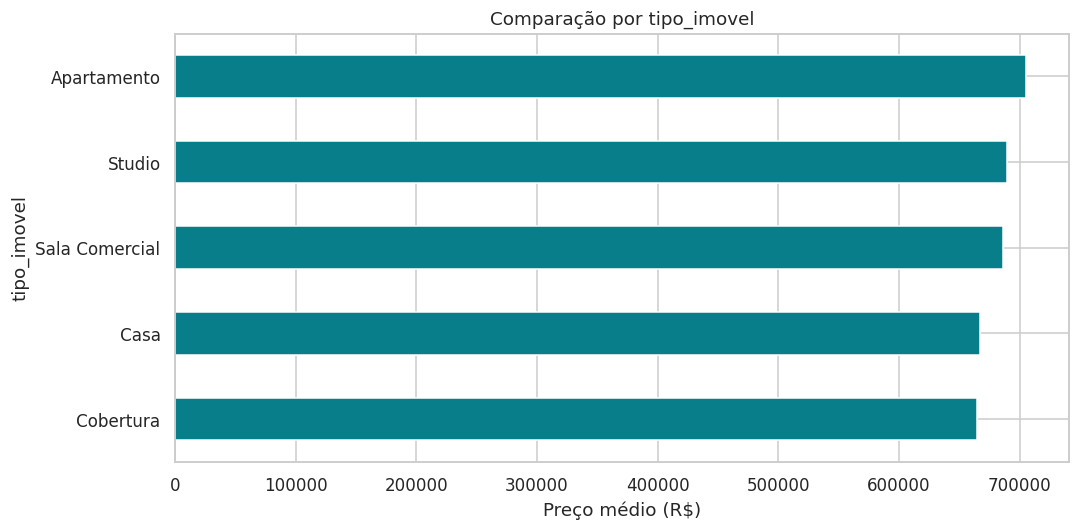

Serra lidera por preço médio; comparar também mediana e quantidade de observações.
Sul lidera por preço médio; comparar também mediana e quantidade de observações.
Apartamento lidera por preço médio; comparar também mediana e quantidade de observações.


In [7]:
for coluna in ['cidade','regiao','tipo_imovel']:
    r = ranking(df,coluna)
    display(r)
    fig, ax = plt.subplots(figsize=(10,5))
    r['mean'].head(12).sort_values().plot.barh(ax=ax,color='#087e8b')
    ax.set(xlabel='Preço médio (R$)', ylabel=coluna, title='Comparação por '+coluna)
    fig.tight_layout(); fig.savefig(IMAGENS/('ranking_'+coluna+'.png'),dpi=160); plt.show()
    print(f'{r.index[0]} lidera por preço médio; comparar também mediana e quantidade de observações.')

In [8]:
cidade_ano = df.pivot_table(index='cidade', columns='ano', values='preco_imovel', aggfunc='mean')
cidade_ano['Variação 2015–2024 (%)'] = (cidade_ano[2024]/cidade_ano[2015]-1)*100
display(cidade_ano[[2015,2024,'Variação 2015–2024 (%)']].sort_values('Variação 2015–2024 (%)', ascending=False))
print('Maior crescimento da média:', cidade_ano['Variação 2015–2024 (%)'].idxmax())

ano,2015,2024,Variação 2015–2024 (%)
cidade,,,
Fortaleza,4.586016e+05,904579.670833,97.247384
Salvador,5.220462e+05,929046.808333,77.962578
Belo Horizonte,5.183633e+05,921860.444167,77.840609
Rio de Janeiro,5.630799e+05,845027.968333,50.072490
Campinas,7.204468e+05,972114.460000,34.932159
Brasília,5.409610e+05,724606.735000,33.948065
Niterói,5.433731e+05,718541.345000,32.237200
São Luís,4.769855e+05,620503.946667,30.088642
Porto Velho,4.534727e+05,569122.678333,25.503173


Maior crescimento da média: Fortaleza


## 8. Heatmap regional e tabela dinâmica

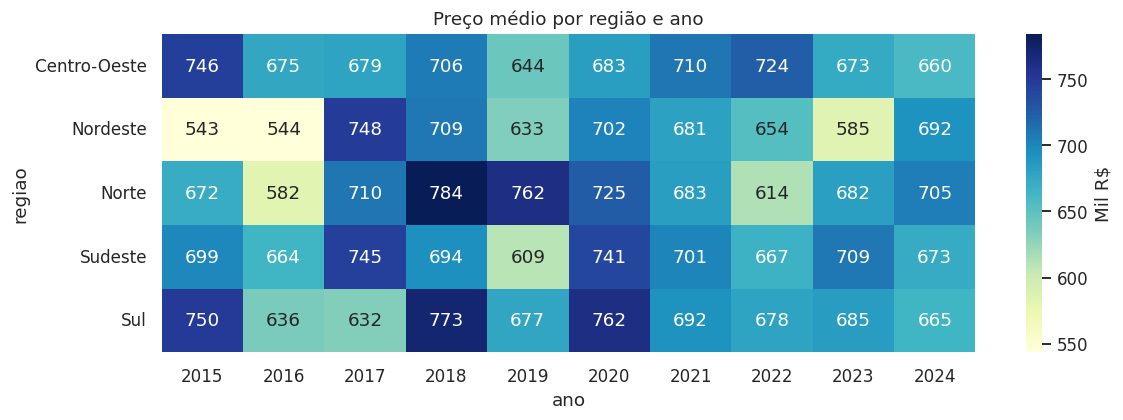

tipo_imovel                            Apartamento  ...         Studio
regiao       cidade                                 ...               
Centro-Oeste Aparecida de Goiânia     5.879955e+05  ...  788353.102692
             Brasília                 7.028357e+05  ...  831493.542500
             Campo Grande             7.343116e+05  ...  875282.823704
             Cuiabá                   6.171084e+05  ...  684640.482105
             Goiânia                  5.371722e+05  ...  685784.312273
Nordeste     Feira de Santana         5.834536e+05  ...  672112.732500
             Fortaleza                9.440093e+05  ...  519690.499600
             Jaboatão dos Guararapes  5.536836e+05  ...  604176.950556
             João Pessoa              6.061602e+05  ...  818282.331034
             Juazeiro do Norte        6.956566e+05  ...  688924.078214
             Recife                   5.343006e+05  ...  696668.048500
             Salvador                 1.251448e+06  ...  539101.040000
             São Luís                 6.420506e+05  ...  648185.250455
Norte        Belém                    6.748621e+05  ...  671974.523333
             Manaus                   6.127167e+05  ...  771559.377308
             Palmas                   5.572440e+05  ...  498140.197500
             Porto Velho              5.797368e+05  ...  590952.613462
             Santarém                 8.497582e+05  ...  749417.544737
Sudeste      Belo Horizonte           7.851251e+05  ...  645076.804167
             Campinas                 8.386123e+05  ...  767200.165000
             Juiz de Fora             8.156393e+05  ...  718136.108667
             Niterói                  6.224162e+05  ...  731880.313913
             Nova Iguaçu              5.242461e+05  ...  782400.940000
             Petrópolis               6.782258e+05  ...  636826.200952
             Ribeirão Preto           8.695775e+05  ...  602694.122917
             Rio de Janeiro           7.600131e+05  ...  824784.685385
             Serra                    7.986492e+05  ...  887225.531905
             São Paulo                8.437709e+05  ...  561945.037917
             Uberlândia               7.224220e+05  ...  624966.831667
             Vila Velha               8.431382e+05  ...  548027.845000
             Vitória                  6.948262e+05  ...  617801.136333
Sul          Caxias do Sul            6.942600e+05  ...  649255.184828
             Curitiba                 6.448429e+05  ...  808772.976667
             Florianópolis            7.954272e+05  ...  701940.311739
             Joinville                7.710553e+05  ...  577257.613684
             Londrina                 6.785989e+05  ...  757279.226087
             Porto Alegre             6.955665e+05  ...  680723.568462

[37 rows x 5 columns]

In [9]:
regional = df.pivot_table(index='regiao', columns='ano', values='preco_imovel', aggfunc='mean')
fig, ax = plt.subplots(figsize=(11,4))
sns.heatmap(regional/1000, annot=True, fmt='.0f', cmap='YlGnBu',ax=ax,cbar_kws={'label':'Mil R$'})
ax.set_title('Preço médio por região e ano'); fig.tight_layout(); fig.savefig(IMAGENS/'heatmap.png',dpi=160); plt.show()
display(df.pivot_table(index=['regiao','cidade'], columns='tipo_imovel', values='preco_imovel',aggfunc='mean'))

## 9. Área, renda e correlação estatística
Dispersão e coeficiente de Pearson medem aspectos diferentes. Pearson descreve associação linear; não prova causalidade e pode ser influenciado por valores extremos.

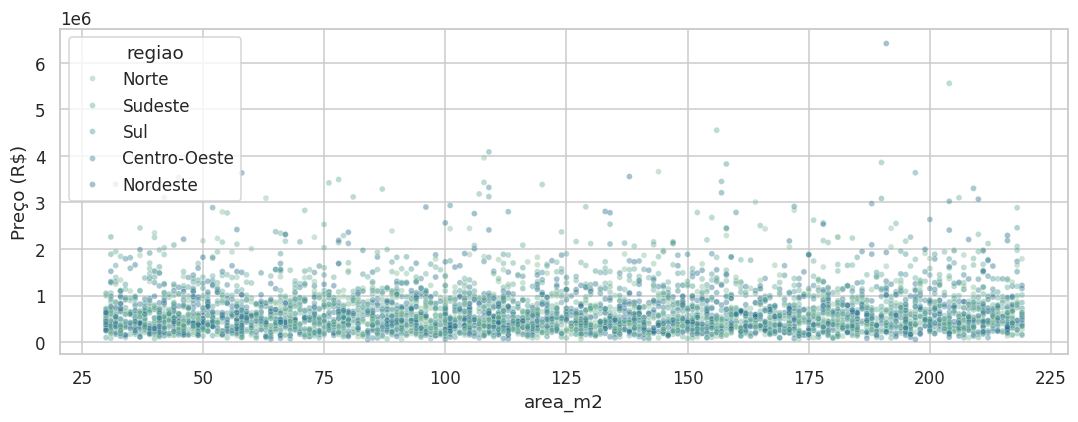

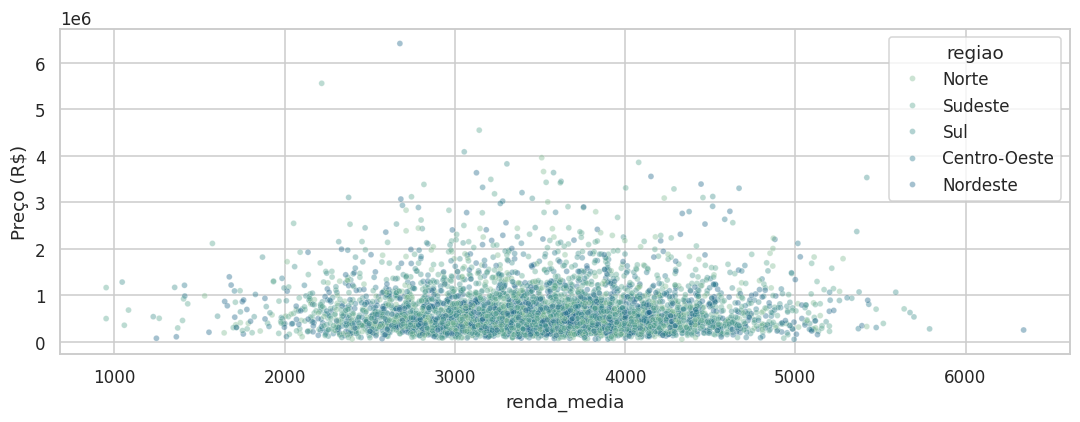

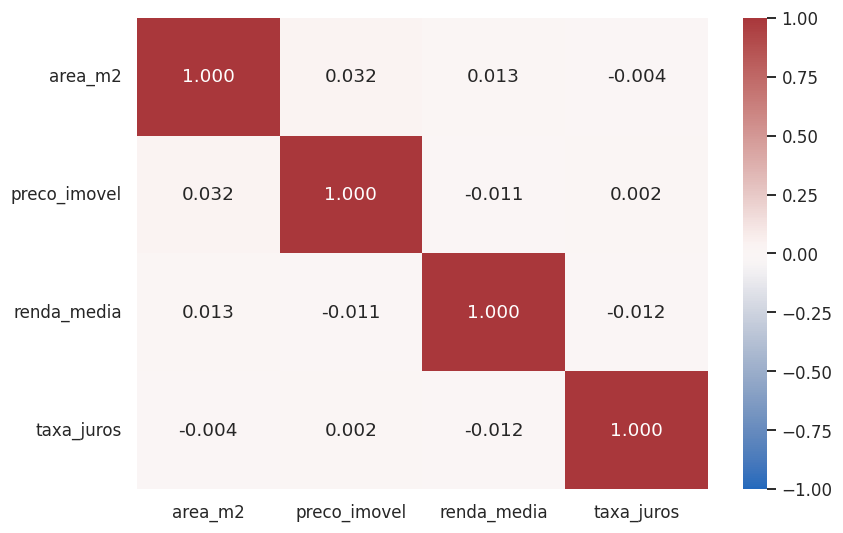

Pearson área/preço: 0.032
Pearson renda/preço: -0.011
Não interpretar correlações desta simulação como evidência sobre relações econômicas reais.


In [10]:
for coluna in ['area_m2','renda_media']:
    fig, ax = plt.subplots(figsize=(10,4))
    sns.scatterplot(data=df,x=coluna,y='preco_imovel',hue='regiao',alpha=.4,s=15,ax=ax)
    ax.set_ylabel('Preço (R$)'); fig.tight_layout(); plt.show()
correlacao = df[['area_m2','preco_imovel','renda_media','taxa_juros']].corr()
fig, ax = plt.subplots(figsize=(8,5))
sns.heatmap(correlacao, annot=True,fmt='.3f',vmin=-1,vmax=1,center=0,cmap='vlag',ax=ax)
fig.tight_layout(); plt.show()
print('Pearson área/preço:', round(correlacao.loc['area_m2','preco_imovel'],3))
print('Pearson renda/preço:', round(correlacao.loc['renda_media','preco_imovel'],3))
print('Não interpretar correlações desta simulação como evidência sobre relações econômicas reais.')

## 10. Persistência em SQLite com SQLAlchemy
A tabela tratada é gravada e consultada por SQL. O banco é reconstruível a partir do CSV. Esta funcionalidade e a correlação estatística atendem às duas funcionalidades avançadas da avaliação geral.

In [11]:
banco = persistir(df)
engine = create_engine(f'sqlite:///{banco}')
with engine.connect() as conn:
    resumo_sql = pd.read_sql(text('SELECT regiao, COUNT(*) AS registros, AVG(preco_imovel) AS preco_medio FROM imoveis GROUP BY regiao ORDER BY preco_medio DESC'),conn)
engine.dispose()
display(resumo_sql)

,regiao,registros,preco_medio
0,Sul,720,695079.957444
1,Norte,600,691901.834567
2,Sudeste,1560,690182.869269
3,Centro-Oeste,600,689971.814200
4,Nordeste,960,649105.927042


## 11. Interpretação e conclusão executiva

In [12]:
print(conclusao(df))

No recorte de 4,440 observações, Serra apresenta o maior preço médio, Sul lidera entre as regiões e Apartamento tem o maior preço médio entre os tipos. A correlação de Pearson entre renda e preço é -0.011. A média das variações anuais comparáveis é 0.32%. As médias refletem a composição da amostra; não acompanham os mesmos imóveis. Os dados são simulados e não permitem conclusões sobre o mercado brasileiro real, causalidade ou recomendações de investimento.


### Limitações e próximos passos
- A base contém 37 cidades, 20 UFs e não possui pesos amostrais.
- Não há identificação longitudinal dos imóveis; a composição varia.
- Preço/m² original inconsistente, substituído nos KPIs por cálculo auditável.
- Renda, juros e níveis de preço são simulados; não há documentação suficiente para inferir condições reais de financiamento.
- Usar dados reais validados, corrigir inflação e comparar imóveis equivalentes seria necessário para uma avaliação econômica.

### Referências
[Base e tema do professor](https://github.com/AlexandreLouzada/Dados-Simulados-G1). Requisitos: documentos da Avaliação G1 fornecidos na atividade. O documento específico tem título G2, mas foi distribuído na atividade G1; adotamos G1 conforme a avaliação e o aviso.